In [29]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [30]:
df = pd.read_csv("Books_Data_Clean.csv")

In [31]:
df.head()

,index,Publishing Year,Book Name,Author,language_code,Author_Rating,Book_average_rating,Book_ratings_count,genre,gross sales,publisher revenue,sale price,sales rank,Publisher,units sold
0,0,1975.0,Beowulf,"Unknown, Seamus Heaney",en-US,Novice,3.42,155903,genre fiction,34160.0,20496.0,4.88,1,HarperCollins Publishers,7000
1,1,1987.0,Batman: Year One,"Frank Miller, David Mazzucchelli, Richmond Lew...",eng,Intermediate,4.23,145267,genre fiction,12437.5,7462.5,1.99,2,HarperCollins Publishers,6250
2,2,2015.0,Go Set a Watchman,Harper Lee,eng,Novice,3.31,138669,genre fiction,47795.0,28677.0,8.69,3,"Amazon Digital Services, Inc.",5500
3,3,2008.0,When You Are Engulfed in Flames,David Sedaris,en-US,Intermediate,4.04,150898,fiction,41250.0,24750.0,7.50,3,Hachette Book Group,5500
4,4,2011.0,Daughter of Smoke & Bone,Laini Taylor,eng,Intermediate,4.04,198283,genre fiction,37952.5,22771.5,7.99,4,Penguin Group (USA) LLC,4750


In [32]:
df.describe()

,index,Publishing Year,Book_average_rating,Book_ratings_count,gross sales,publisher revenue,sale price,sales rank,units sold
count,1070.000000,1069.000000,1070.000000,1070.000000,1070.000000,1070.000000,1070.000000,1070.000000,1070.000000
mean,534.500000,1971.377923,4.007000,94909.913084,1856.622944,843.281030,4.869561,611.652336,9676.980374
std,309.026698,185.080257,0.247244,31513.242518,3936.924240,2257.596743,3.559919,369.849830,15370.571306
min,0.000000,-560.000000,2.970000,27308.000000,104.940000,0.000000,0.990000,1.000000,106.000000
25%,267.250000,1985.000000,3.850000,70398.000000,372.465000,0.000000,1.990000,287.500000,551.250000
50%,534.500000,2003.000000,4.015000,89309.000000,809.745000,273.078000,3.990000,595.500000,3924.000000
75%,801.750000,2010.000000,4.170000,113906.500000,1487.957500,721.180500,6.990000,932.500000,5312.250000
max,1069.000000,2016.000000,4.770000,206792.000000,47795.000000,28677.000000,33.860000,1273.000000,61560.000000


In [33]:
df=df[df["Publishing Year"]>1900]

In [34]:
df.isna().sum()

index                   0
Publishing Year         0
Book Name              21
Author                  0
language_code          49
Author_Rating           0
Book_average_rating     0
Book_ratings_count      0
genre                   0
gross sales             0
publisher revenue       0
sale price              0
sales rank              0
Publisher               0
units sold              0
dtype: int64

In [35]:
//df=df.dropna(subset="Book Name")
df.dropna(subset="Book Name", inplace=True)

SyntaxError: invalid syntax (1520792321.py, line 1)

In [ ]:
df.duplicated().sum()

np.int64(0)

In [ ]:
df.nunique()

index                  988
Publishing Year        101
Book Name              987
Author                 669
language_code            8
Author_Rating            4
Book_average_rating    133
Book_ratings_count     983
genre                    4
gross sales            774
publisher revenue      570
sale price             143
sales rank             818
Publisher                9
units sold             470
dtype: int64

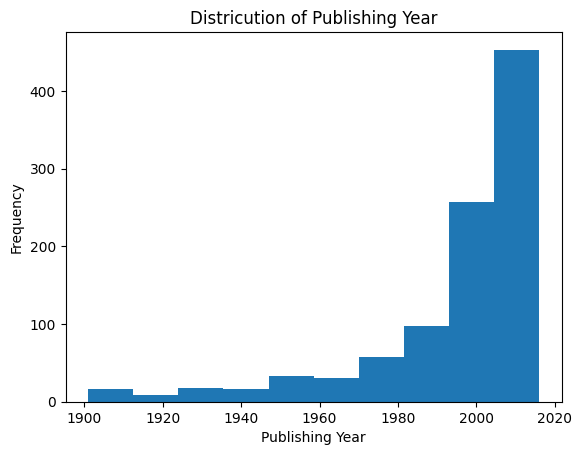

In [ ]:
plt.hist(df["Publishing Year"])
plt.xlabel("Publishing Year")
plt.ylabel("Frequency")
plt.title("Districution of Publishing Year")
plt.show()

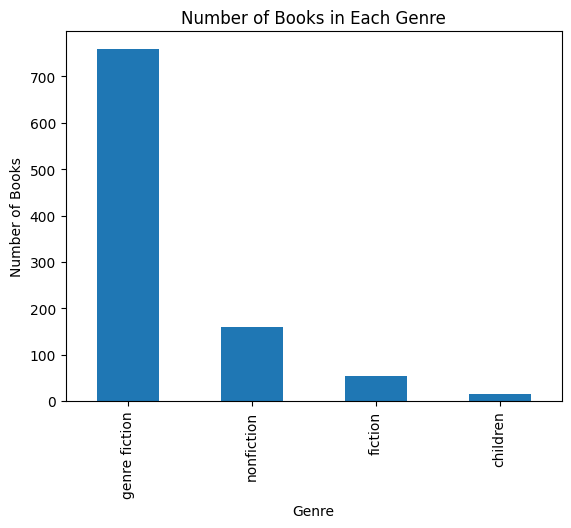

In [ ]:
df["genre"].value_counts().plot(kind="bar")
plt.xlabel("Genre")
plt.ylabel("Number of Books")
plt.title("Number of Books in Each Genre")
plt.show()

In [ ]:
df.groupby("Author")["Book_average_rating"].mean().sort_values(ascending=False)

Author
Bill Watterson                  4.650000
Bill Watterson, G.B. Trudeau    4.610000
J.R.R. Tolkien                  4.590000
George R.R. Martin              4.560000
Sarah J. Maas                   4.526000
                                  ...   
Chetan Bhagat                   3.273333
Audrey Niffenegger              3.230000
Herman Koch, Sam Garrett        3.220000
P.D. James                      3.210000
Sue Monk Kidd                   3.100000
Name: Book_average_rating, Length: 669, dtype: float64

C:\Users\narme\AppData\Local\Temp\ipykernel_16276\4087639960.py:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x="genre", y="Book_ratings_count", data=df,  palette="Set1")


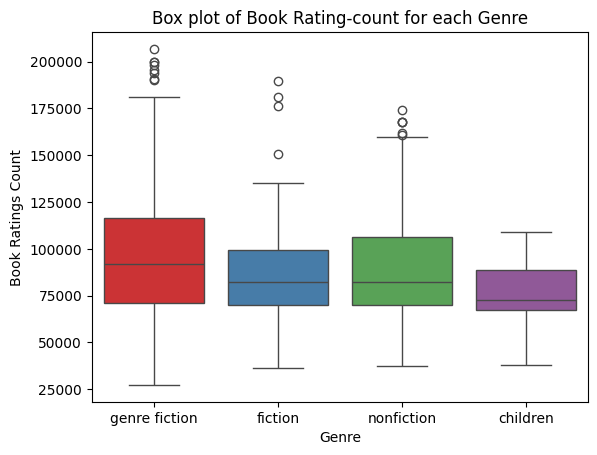

In [ ]:
sns.boxplot(x="genre", y="Book_ratings_count", data=df,  palette="Set1")
plt.xlabel("Genre")
plt.ylabel("Book Ratings Count")
plt.title("Box plot of Book Rating-count for each Genre")
plt.show()

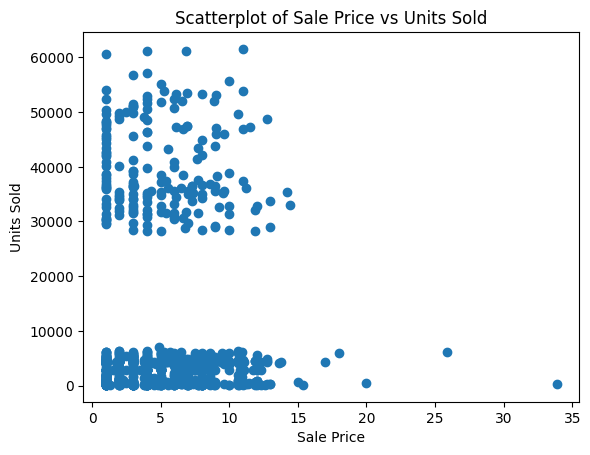

In [ ]:
plt.scatter(df["sale price"], df["units sold"])
plt.xlabel("Sale Price")
plt.ylabel("Units Sold")
plt.title("Scatterplot of Sale Price vs Units Sold")
plt.show()

In [ ]:
df["language_code"].value_counts().sort_values(ascending=True)

language_code
nl         1
spa        2
ara        2
fre        4
en-CA      7
en-GB     29
en-US    226
eng      670
Name: count, dtype: int64

In [36]:
language_counts=df["language_code"].value_counts()

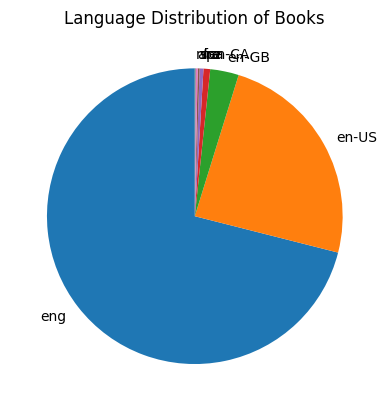

In [40]:
plt.pie(language_counts, labels=language_counts.index, startangle=90)
plt.title("Language Distribution of Books")
plt.show()

In [42]:
df.groupby ("Publisher ")["publisher revenue"].sum().sort_values(ascending=False)

Publisher 
Penguin Group (USA) LLC                 202987.308
Random House LLC                        185744.244
Amazon Digital Services,  Inc.          144415.350
HarperCollins Publishers                124264.770
Hachette Book Group                     108446.700
Simon and Schuster Digital Sales Inc     46858.206
Macmillan                                31249.830
HarperCollins Publishing                  2830.806
HarperCollins Christian Publishing        2135.670
Name: publisher revenue, dtype: float64

In [46]:
df.groupby ("Author_Rating")["Book_ratings_count"].mean().sort_values(ascending=False).max()

np.float64(101710.1529209622)

In [47]:
df.groupby("language_code").size().sort_values(ascending=False)

language_code
eng      682
en-US    232
en-GB     30
en-CA      7
fre        4
ara        2
spa        2
nl         1
dtype: int64

In [49]:
df.groupby("Author_Rating")["Book_ratings_count"].var()

Author_Rating
Excellent       4.353006e+08
Famous          1.215158e+09
Intermediate    1.182667e+09
Novice          9.523157e+08
Name: Book_ratings_count, dtype: float64

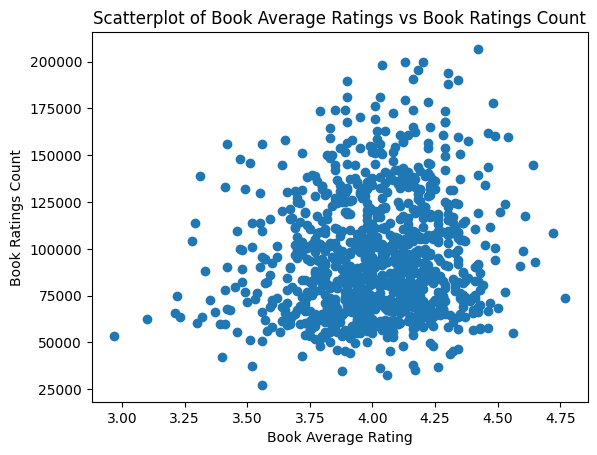

In [51]:
plt.scatter(df["Book_average_rating"], df["Book_ratings_count"])
plt.xlabel("Book Average Rating")
plt.ylabel("Book Ratings Count")
plt.title("Scatterplot of Book Average Ratings vs Book Ratings Count")
plt.show()

In [52]:
total_gross_sales_by_author=df.groupby("Author")["gross sales"].sum()

In [53]:
total_gross_sales_by_author

Author
A.A. Milne, Ernest H. Shepard                       214.92
A.S.A. Harrison                                     784.16
Abbi Glines                                        2990.16
Adam Johnson                                        108.90
Adam Mansbach, Ricardo CortÃ©s                      113.85
                                                    ...   
William Styron                                      220.89
Yana Toboso, Tomo Kimura                           1366.86
Zadie Smith                                         167.31
Ø£Ø­Ù„Ø§Ù… Ù…Ø³ØªØºØ§Ù†Ù…ÙŠ, Ahlam Mosteghanemi    1200.10
Ø£Ø­Ù…Ø¯ Ù…Ø±Ø§Ø¯                                  1128.87
Name: gross sales, Length: 680, dtype: float64

In [56]:
total_gross_sales_by_author.sort_values(ascending=False)

Author
Harper Lee                         47795.00
Stephen King                       43322.65
David Sedaris                      42323.41
Charlaine Harris                   39453.08
Laini Taylor                       38278.41
                                     ...   
Guillermo del Toro, Chuck Hogan      107.91
Ayaan Hirsi Ali                      107.91
Walter M. Miller Jr.                 106.92
Michael Shaara                       105.93
Blake Crouch                         105.93
Name: gross sales, Length: 680, dtype: float64

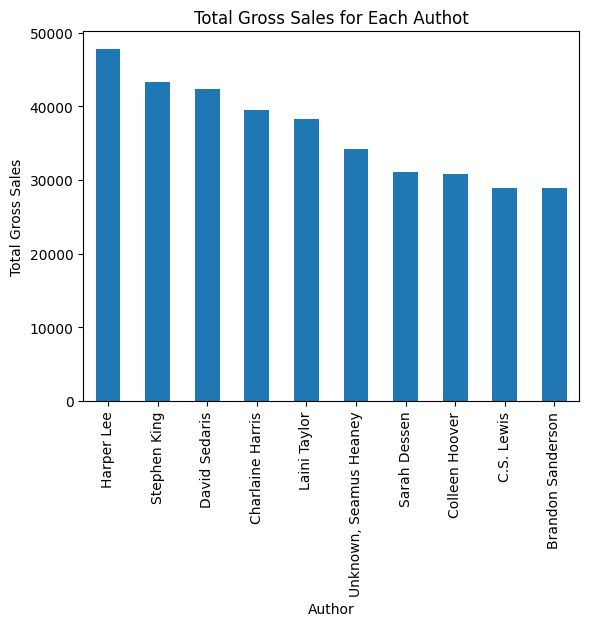

In [61]:
total_gross_sales_by_author.sort_values(ascending=False).head(10).plot(kind="bar")
plt.xlabel("Author")
plt.ylabel("Total Gross Sales")
plt.title("Total Gross Sales for Each Authot")
plt.show()

C:\Users\narme\AppData\Local\Temp\ipykernel_16276\216524198.py:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x="Author_Rating", y="units sold", data=df, palette="Set1")


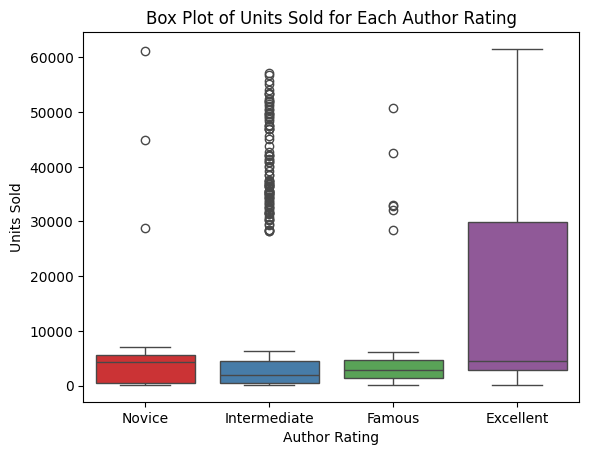

In [64]:
sns.boxplot(x="Author_Rating", y="units sold", data=df, palette="Set1")
plt.xlabel("Author Rating")
plt.ylabel("Units Sold")
plt.title("Box Plot of Units Sold for Each Author Rating")
plt.show()

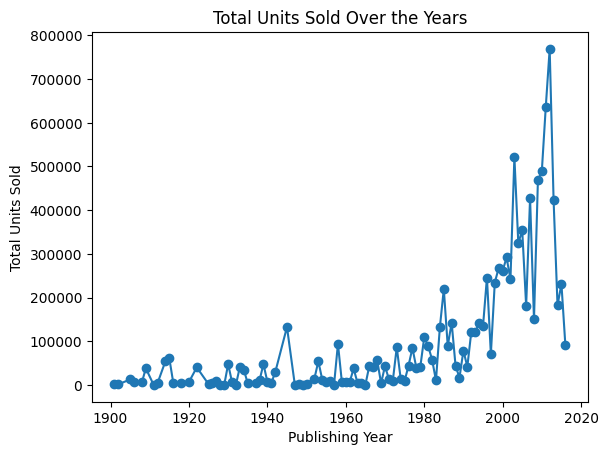

In [66]:
df.groupby("Publishing Year")["units sold"].sum().plot(kind="line", marker="o")
plt.xlabel("Publishing Year")
plt.ylabel("Total Units Sold")
plt.title("Total Units Sold Over the Years")
plt.show()